# Lab 2

## 1. Analyzing Iris Dataset 

In [1]:
import pandas as pd
iris = pd.read_csv("Iris.csv")

### (a) How many instances (examples) are in the dataset.

In [2]:
numberofInstances = iris.shape[0]
print("Number of instances: " + str(numberofInstances))

Number of instances: 150


### (b) How many attributes (columns) are there? What are their names?

In [3]:
numberofAttributes = len(iris.columns)
print("Number of attributes: " + str(numberofAttributes))

Number of attributes: 6


### (c) For For each of the attributes: What is the range of values (minimum and maximum)? What is the average, standard deviation and median of the values?

In [4]:
print(iris.describe())

               Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
count  150.000000     150.000000    150.000000     150.000000    150.000000
mean    75.500000       5.843333      3.054000       3.758667      1.198667
std     43.445368       0.828066      0.433594       1.764420      0.763161
min      1.000000       4.300000      2.000000       1.000000      0.100000
25%     38.250000       5.100000      2.800000       1.600000      0.300000
50%     75.500000       5.800000      3.000000       4.350000      1.300000
75%    112.750000       6.400000      3.300000       5.100000      1.800000
max    150.000000       7.900000      4.400000       6.900000      2.500000


### (d) What are the possible output names (species)?

In [5]:
uniqueSpecies = iris["Species"].unique()

for s in uniqueSpecies:
    print(s)

Iris-setosa
Iris-versicolor
Iris-virginica


## 2. Visually Exploring Data 

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt
nonIdIris = iris.drop(columns=["Id"])

### (a) Which one of the attributes has the largest/smallest variance? Make a plot that easily shows the answer.

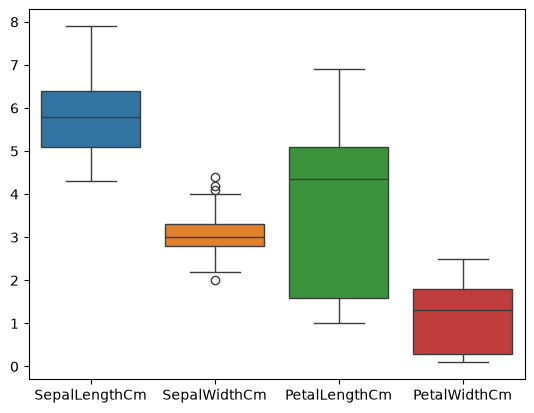

In [7]:
sns.boxplot(data=nonIdIris)
plt.show()

### (b) Does the variance of the attributes depend on the species? Make a plot that easily shows the answer.

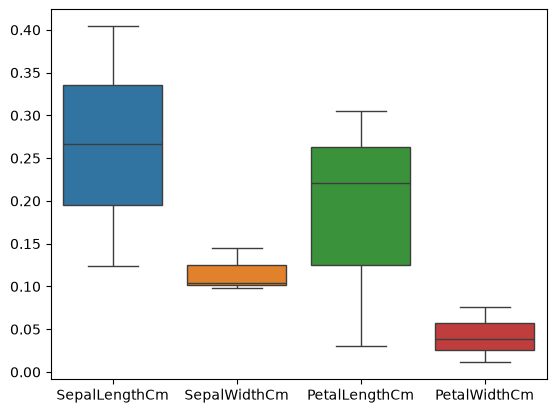

In [8]:
plt.clf()
irisGrouped = nonIdIris.groupby("Species").var()
sns.boxplot(data=irisGrouped)
plt.show()

### (c) Which of the three species can be easily (linearly) separated from the remaining two? Write down a simple rule of the form ”If attribute X < | > V then class = Y else class != Y”, that is, pick an attribute and a threshold value that best separates one class from the others. Generate a plot that supports your rule.

SepalLengthCm
                 min  max
Species                  
Iris-setosa      4.3  5.8
Iris-versicolor  4.9  7.0
Iris-virginica   4.9  7.9

SepalWidthCm
                 min  max
Species                  
Iris-setosa      2.3  4.4
Iris-versicolor  2.0  3.4
Iris-virginica   2.2  3.8

PetalLengthCm
                 min  max
Species                  
Iris-setosa      1.0  1.9
Iris-versicolor  3.0  5.1
Iris-virginica   4.5  6.9

PetalWidthCm
                 min  max
Species                  
Iris-setosa      0.1  0.6
Iris-versicolor  1.0  1.8
Iris-virginica   1.4  2.5



<Axes: xlabel='PetalLengthCm', ylabel='Count'>

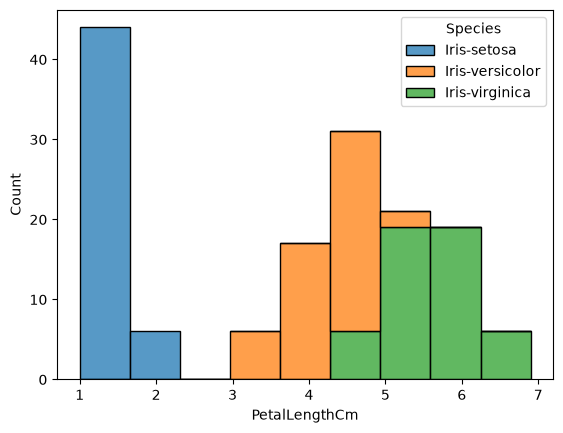

In [9]:
for col in nonIdIris.select_dtypes("number").columns:
    print(col)
    print(nonIdIris.groupby("Species")[col].agg(["min", "max"]))
    print()

sns.histplot(data=nonIdIris, x="PetalLengthCm", hue="Species", multiple="stack")

## 3. Analyzing Titanic Dataset

In [10]:
import pandas as pd
titanic = pd.read_csv("titanic.csv")

(a) (20 points) Explore the effects of the ”woman and children first” policy on the survival rate.
(The ”who” attribute might come in handy for this.) What can be said about the effects of
that policy depending on the class of the passenger? Generate one or more graphs that support
your conclusions.

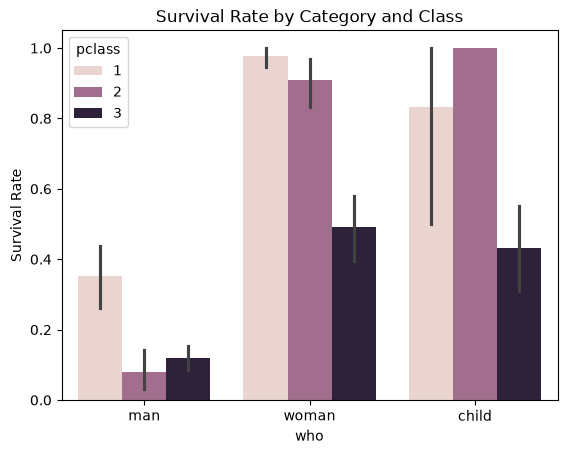

In [11]:
sns.barplot(data=titanic, x="who", y="survived", hue="pclass",
            order=["man", "woman", "child"])
plt.title("Survival Rate by Category and Class")
plt.ylabel("Survival Rate")
plt.show()

We can see that women and children cleary survived more, meaning that the rule had alot to do with the survival rate of the passengers. We can also see that the passengers in the higher classes were more likely to survive than the lower classes. Although male in the third class had a higher survival than those in the second class and the same can be said for children where children in the middle class had a higher survival chance than those in the first class

(b) (30 points) Generate at least two graphs of different type (box plot, scatter plot, histogram,
bar plot, line plot) that show some interesting facts about the passengers and describe what
can be seen in the graphs. (For example, you could look at the distribution of attribute val-
ues, correlations between different attributes, or correlations between pairs of attributes and
survival.)

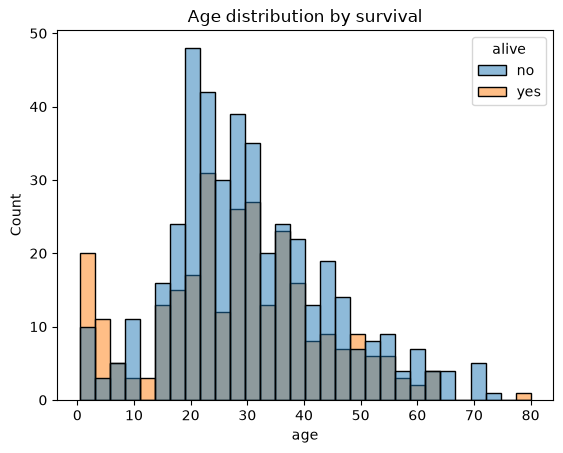

In [12]:
sns.histplot(data=titanic, x="age", hue="alive", bins=30)
plt.title("Age distribution by survival")
plt.show()

This histogram shows the age distribution of passengers by their survival.
We can see that most passengers are between the ages of 20 and 35, but we also see a spike in young children around the age of 0 and 5. From this we also see that children had a noticeble survival rate over the rest of the ages. This was probably due to the women and children first rule where boys and girls were given chances over men.